<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Konvol%C3%BAci%C3%B3s%20R%C3%A9tegek%20Alapjai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Konvolúciós Rétegek Alapjai

Ebben a notebookban a **konvolúciós rétegek** alapjait vizsgáljuk.

## Tartalomjegyzék

1. Konvolúció alapok
2. Filterek és feature map-ek
3. Stride és Padding
4. Receptive Field
5. PyTorch Conv2d

## 1. Konvolúció alapok

### Mi a konvolúció?

| Tulajdonság | Leírás |
|-------------|--------|
| Lokális kapcsolat | Csak szomszédos pixeleket néz |
| Súlymegosztás | Ugyanaz a filter az egész képen |
| Transzláció invariancia | Pozíciótól független felismerés |

### Matematikai definíció

$$(I * K)(i, j) = \sum_m \sum_n I(i+m, j+n) \cdot K(m, n)$$

ahol $I$ a bemeneti kép, $K$ a kernel/filter.

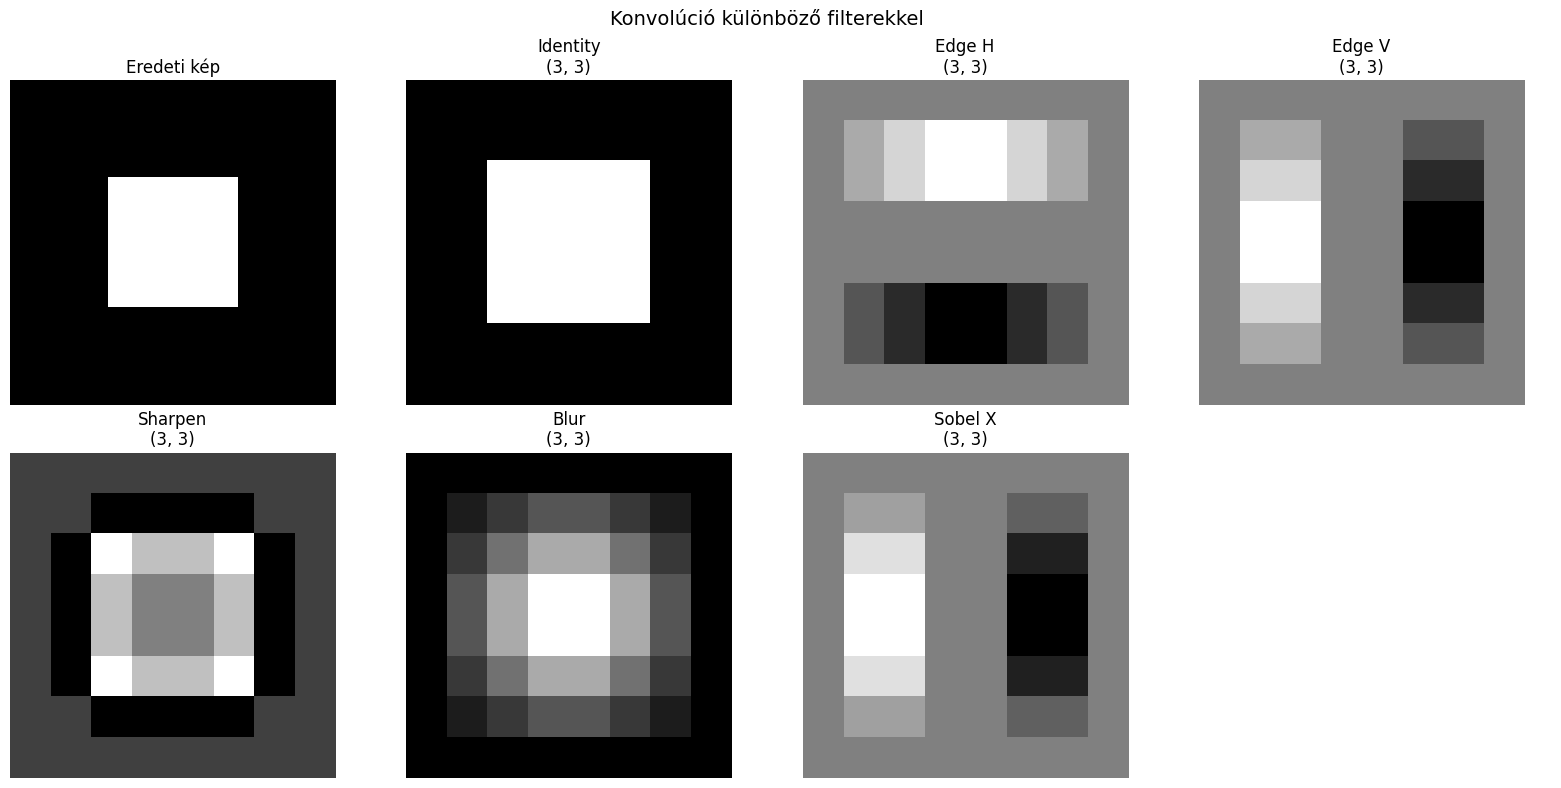

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)

# Egyszerű 2D konvolúció implementáció
def conv2d_numpy(image, kernel):
    """2D konvolúció numpy-val."""
    h, w = image.shape
    kh, kw = kernel.shape

    # Output méret (valid convolution)
    out_h = h - kh + 1
    out_w = w - kw + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            # Kivágás és elemenkénti szorzás
            patch = image[i:i+kh, j:j+kw]
            output[i, j] = np.sum(patch * kernel)

    return output

# Teszt kép
image = np.zeros((10, 10))
image[3:7, 3:7] = 1  # Négyzet a közepén

# Különböző filterek
kernels = {
    'Identity': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
    'Edge H': np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]]),
    'Edge V': np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]),
    'Sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
    'Blur': np.ones((3, 3)) / 9,
    'Sobel X': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Eredeti kép
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Eredeti kép')
axes[0, 0].axis('off')

# Konvolúciók
for ax, (name, kernel) in zip(axes.ravel()[1:], kernels.items()):
    output = conv2d_numpy(image, kernel)
    ax.imshow(output, cmap='gray')
    ax.set_title(f'{name}\n{kernel.shape}')
    ax.axis('off')

axes[1, 3].axis('off')
plt.suptitle('Konvolúció különböző filterekkel', fontsize=14)
plt.tight_layout()
plt.show()

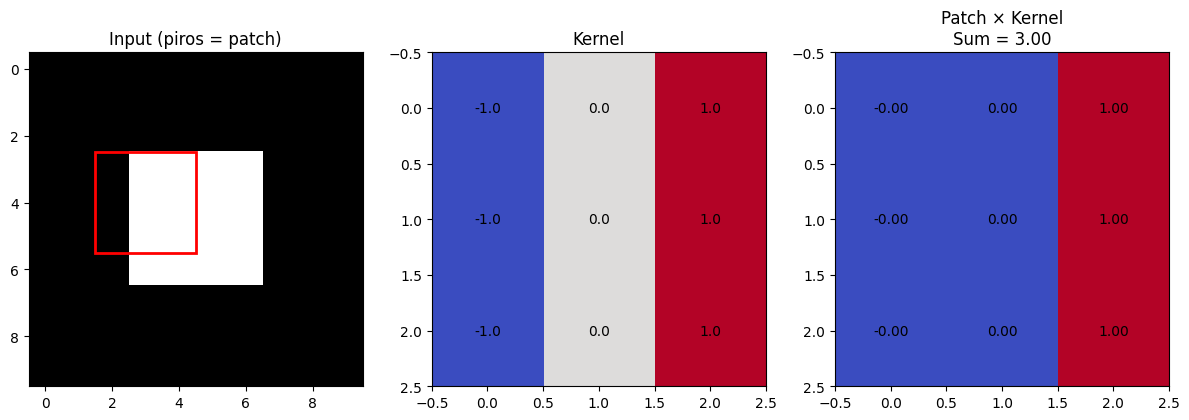

In [6]:
# Konvolúció animáció/vizualizáció

def visualize_convolution_step(image, kernel, step_i, step_j):
    """Egy konvolúciós lépés vizualizálása."""
    kh, kw = kernel.shape

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Input kép a kijelölt patch-el
    axes[0].imshow(image, cmap='gray')
    rect = plt.Rectangle((step_j-0.5, step_i-0.5), kw, kh,
                          fill=False, color='red', linewidth=2)
    axes[0].add_patch(rect)
    axes[0].set_title('Input (piros = patch)')

    # Kernel
    axes[1].imshow(kernel, cmap='coolwarm')
    for i in range(kh):
        for j in range(kw):
            axes[1].text(j, i, f'{kernel[i,j]:.1f}', ha='center', va='center')
    axes[1].set_title('Kernel')

    # Elemenkénti szorzat
    patch = image[step_i:step_i+kh, step_j:step_j+kw]
    product = patch * kernel
    result = product.sum()

    axes[2].imshow(product, cmap='coolwarm')
    for i in range(kh):
        for j in range(kw):
            axes[2].text(j, i, f'{product[i,j]:.2f}', ha='center', va='center')
    axes[2].set_title(f'Patch × Kernel\nSum = {result:.2f}')

    plt.tight_layout()
    plt.show()

# Példa
edge_kernel = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
visualize_convolution_step(image, edge_kernel, step_i=3, step_j=2)

## 2. Filterek és feature map-ek

### Többcsatornás konvolúció

RGB kép esetén:
- Input: $(C_{in}, H, W)$ - pl. $(3, 224, 224)$
- Kernel: $(C_{in}, K_h, K_w)$ - pl. $(3, 3, 3)$
- Output: $(H_{out}, W_{out})$ - egy feature map

### Több filter = több feature map

- $N$ különböző filter → $N$ feature map
- Output: $(N, H_{out}, W_{out})$

Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 8, 32, 32])
Paraméterek: 224 (weights + bias)


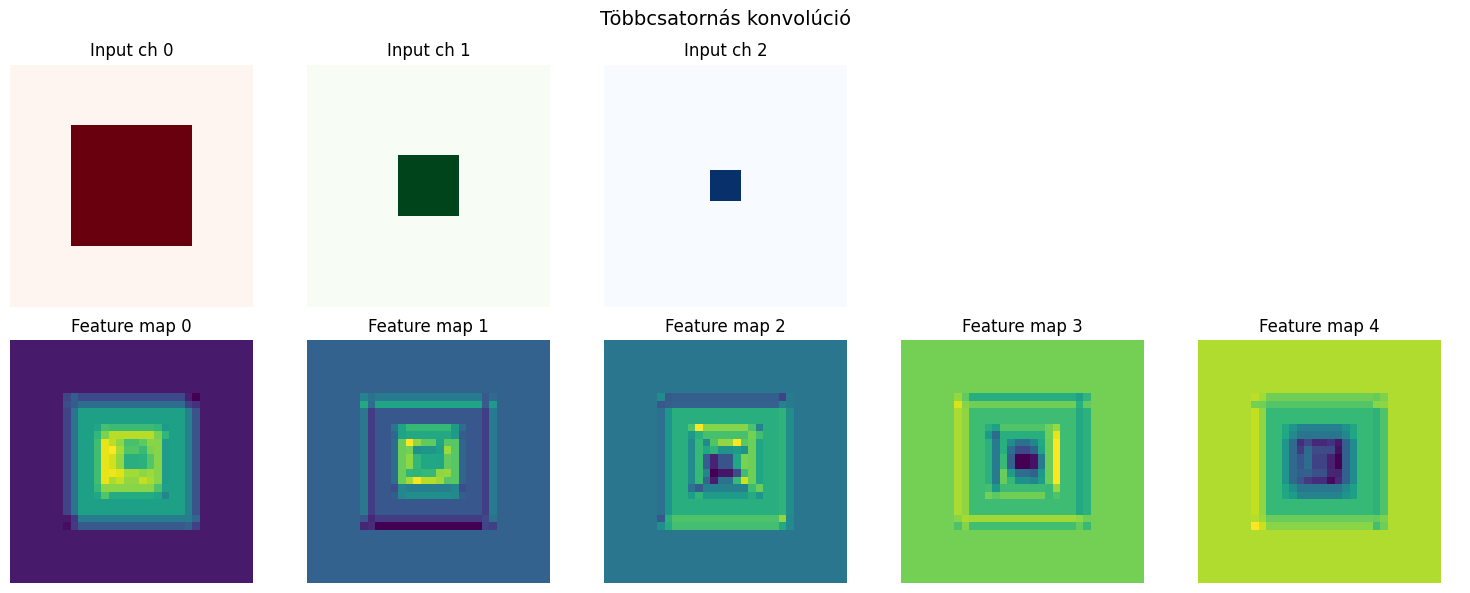

In [7]:
# Többcsatornás konvolúció

# Szintetikus RGB kép
rgb_image = np.zeros((3, 32, 32))
rgb_image[0, 8:24, 8:24] = 1  # R - nagy négyzet
rgb_image[1, 12:20, 12:20] = 1  # G - közepes négyzet
rgb_image[2, 14:18, 14:18] = 1  # B - kis négyzet

# PyTorch tensor
x = torch.FloatTensor(rgb_image).unsqueeze(0)  # (1, 3, 32, 32)

# Conv layer: 3 input channel, 8 output channel, 3x3 kernel
conv = nn.Conv2d(3, 8, kernel_size=3, padding=1)

with torch.no_grad():
    feature_maps = conv(x)  # (1, 8, 32, 32)

print(f"Input shape: {x.shape}")
print(f"Output shape: {feature_maps.shape}")
print(f"Paraméterek: {3 * 8 * 3 * 3 + 8} (weights + bias)")

# Vizualizáció
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Input channels
for i, (ax, color) in enumerate(zip(axes[0, :3], ['Reds', 'Greens', 'Blues'])):
    ax.imshow(rgb_image[i], cmap=color)
    ax.set_title(f'Input ch {i}')
    ax.axis('off')

axes[0, 3].axis('off')
axes[0, 4].axis('off')

# Feature maps (első 5)
for i, ax in enumerate(axes[1]):
    ax.imshow(feature_maps[0, i].numpy(), cmap='viridis')
    ax.set_title(f'Feature map {i}')
    ax.axis('off')

plt.suptitle('Többcsatornás konvolúció', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Stride és Padding

### Output méret számítás

$$H_{out} = \lfloor \frac{H_{in} + 2P - K}{S} \rfloor + 1$$

ahol:
- $P$ = padding
- $K$ = kernel méret
- $S$ = stride

### Padding típusok

| Típus | Leírás | Output méret |
|-------|--------|-------------|
| Valid | Nincs padding | Kisebb |
| Same | P = K//2 | Ugyanaz |
| Full | P = K-1 | Nagyobb |

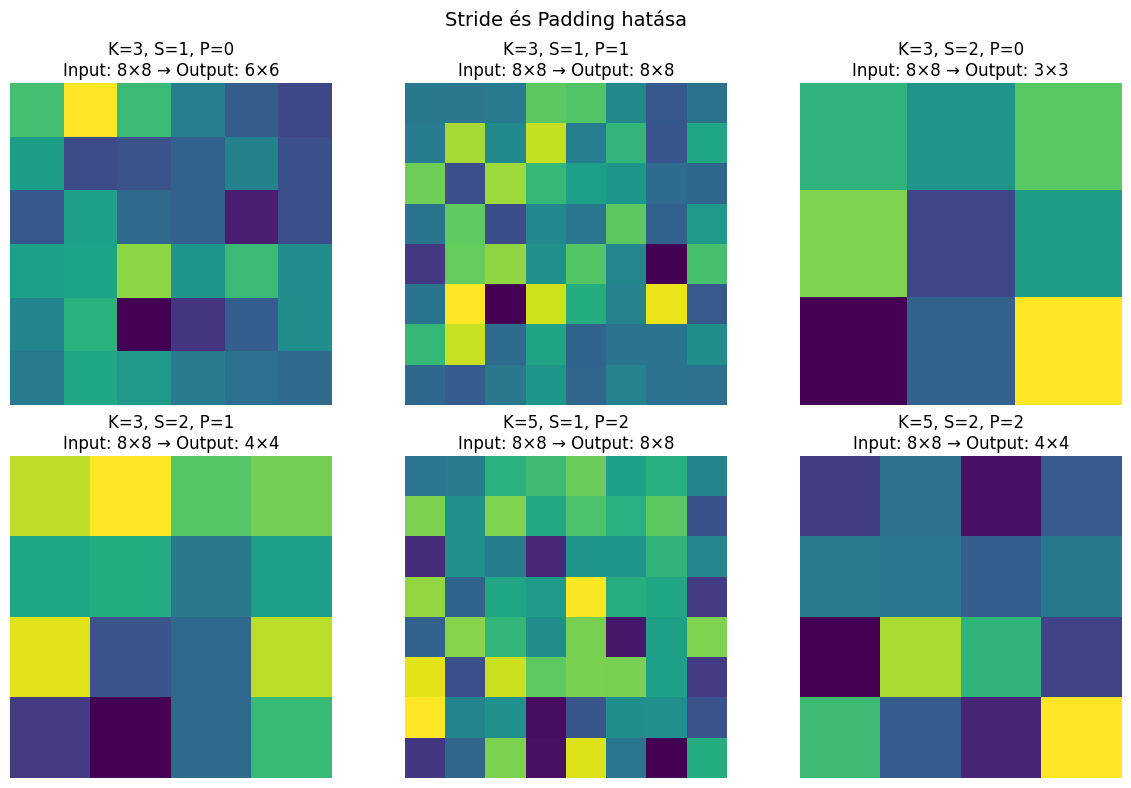

In [8]:
# Stride és Padding hatása

x = torch.randn(1, 1, 8, 8)

configs = [
    {'kernel_size': 3, 'stride': 1, 'padding': 0},  # Valid
    {'kernel_size': 3, 'stride': 1, 'padding': 1},  # Same
    {'kernel_size': 3, 'stride': 2, 'padding': 0},  # Stride 2
    {'kernel_size': 3, 'stride': 2, 'padding': 1},  # Stride 2 + padding
    {'kernel_size': 5, 'stride': 1, 'padding': 2},  # 5x5 Same
    {'kernel_size': 5, 'stride': 2, 'padding': 2},  # 5x5 Stride 2
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for ax, cfg in zip(axes, configs):
    conv = nn.Conv2d(1, 1, **cfg)
    with torch.no_grad():
        out = conv(x)

    # Vizualizáció
    ax.imshow(out[0, 0].numpy(), cmap='viridis')
    ax.set_title(f"K={cfg['kernel_size']}, S={cfg['stride']}, P={cfg['padding']}\n"
                 f"Input: 8×8 → Output: {out.shape[2]}×{out.shape[3]}")
    ax.axis('off')

plt.suptitle('Stride és Padding hatása', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Output méret kalkulátor

def calc_output_size(h_in, w_in, kernel, stride=1, padding=0, dilation=1):
    """Konvolúciós output méret számítása."""
    h_out = (h_in + 2*padding - dilation*(kernel-1) - 1) // stride + 1
    w_out = (w_in + 2*padding - dilation*(kernel-1) - 1) // stride + 1
    return h_out, w_out

# Példa: ImageNet pipeline
print("Tipikus CNN dimenzió változások (224×224 input):")
print("="*50)

h, w = 224, 224
layers = [
    ('Conv 7×7, s=2, p=3', 7, 2, 3),
    ('MaxPool 3×3, s=2, p=1', 3, 2, 1),
    ('Conv 3×3, s=1, p=1', 3, 1, 1),
    ('Conv 3×3, s=2, p=1', 3, 2, 1),
    ('Conv 3×3, s=1, p=1', 3, 1, 1),
    ('Conv 3×3, s=2, p=1', 3, 2, 1),
]

print(f"Input: {h}×{w}")
for name, k, s, p in layers:
    h, w = calc_output_size(h, w, k, s, p)
    print(f"{name:25} → {h}×{w}")

Tipikus CNN dimenzió változások (224×224 input):
Input: 224×224
Conv 7×7, s=2, p=3        → 112×112
MaxPool 3×3, s=2, p=1     → 56×56
Conv 3×3, s=1, p=1        → 56×56
Conv 3×3, s=2, p=1        → 28×28
Conv 3×3, s=1, p=1        → 28×28
Conv 3×3, s=2, p=1        → 14×14


## 4. Receptive Field

### Definíció

A receptive field az input kép azon régiója, ami hatással van egy adott output neuronra.

### Receptive field növelése

- Több réteg egymás után
- Nagyobb kernel
- Pooling
- Dilated/Atrous convolution

VGG-szerű architektúra receptive field:
Input      RF:   1  Jump: 1
Conv1      RF:   3  Jump: 1
Conv2      RF:   5  Jump: 1
Pool1      RF:   6  Jump: 2
Conv3      RF:  10  Jump: 2
Conv4      RF:  14  Jump: 2
Pool2      RF:  16  Jump: 4
Conv5      RF:  24  Jump: 4
Conv6      RF:  32  Jump: 4
Conv7      RF:  40  Jump: 4
Pool3      RF:  44  Jump: 8


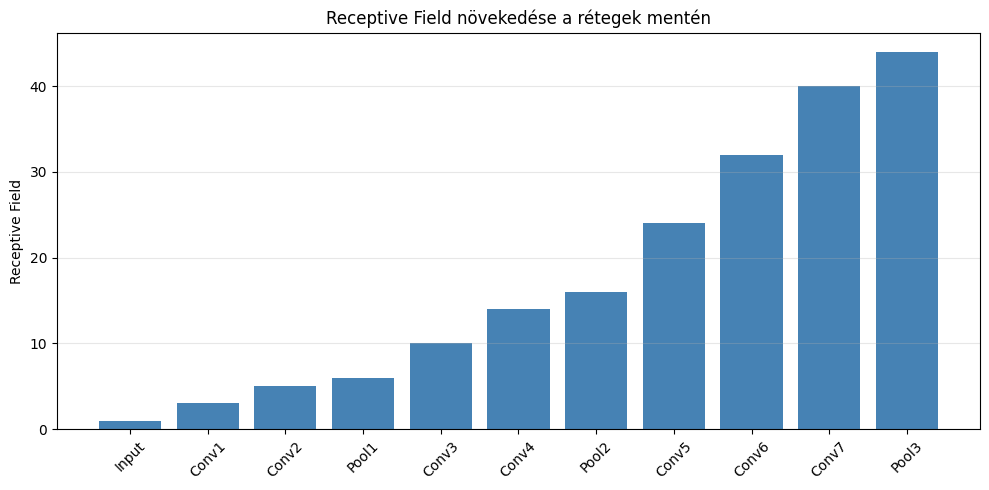

In [10]:
# Receptive field számítás

def calc_receptive_field(layers):
    """Receptive field és jump számítása.

    layers: list of (kernel_size, stride, padding)
    """
    rf = 1  # Receptive field
    jump = 1  # Jump (stride hatása)

    history = [(1, 1)]  # (rf, jump)

    for k, s, p in layers:
        rf = rf + (k - 1) * jump
        jump = jump * s
        history.append((rf, jump))

    return rf, history

# VGG-szerű architektúra
vgg_layers = [
    (3, 1, 1),  # conv1
    (3, 1, 1),  # conv2
    (2, 2, 0),  # pool
    (3, 1, 1),  # conv3
    (3, 1, 1),  # conv4
    (2, 2, 0),  # pool
    (3, 1, 1),  # conv5
    (3, 1, 1),  # conv6
    (3, 1, 1),  # conv7
    (2, 2, 0),  # pool
]

rf, history = calc_receptive_field(vgg_layers)

print("VGG-szerű architektúra receptive field:")
print("="*40)
layer_names = ['Input', 'Conv1', 'Conv2', 'Pool1', 'Conv3', 'Conv4', 'Pool2',
               'Conv5', 'Conv6', 'Conv7', 'Pool3']

for name, (r, j) in zip(layer_names, history):
    print(f"{name:10} RF: {r:3}  Jump: {j}")

# Vizualizáció
rfs = [h[0] for h in history]
plt.figure(figsize=(10, 5))
plt.bar(range(len(rfs)), rfs, color='steelblue')
plt.xticks(range(len(rfs)), layer_names, rotation=45)
plt.ylabel('Receptive Field')
plt.title('Receptive Field növekedése a rétegek mentén')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

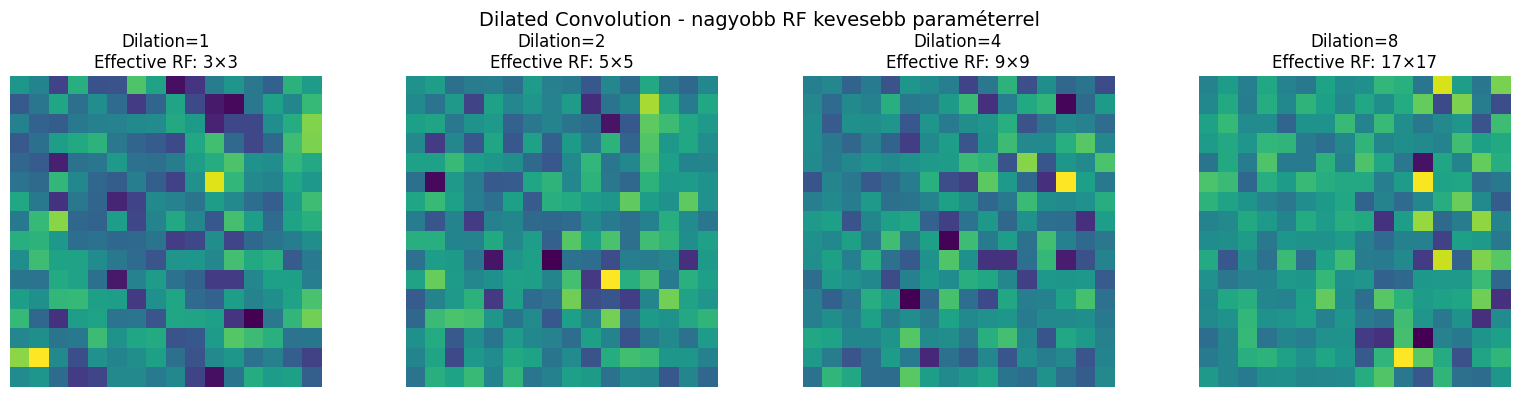

In [12]:
# Dilated convolution

x = torch.randn(1, 1, 16, 16)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

dilations = [1, 2, 4, 8]

for ax, d in zip(axes, dilations):
    conv = nn.Conv2d(1, 1, kernel_size=3, padding=d, dilation=d)
    with torch.no_grad():
        out = conv(x)

    # Effective receptive field
    eff_kernel = 3 + (3-1) * (d-1)  # = d*2 + 1

    ax.imshow(out[0, 0].numpy(), cmap='viridis')
    ax.set_title(f'Dilation={d}\nEffective RF: {eff_kernel}×{eff_kernel}')
    ax.axis('off')

plt.suptitle('Dilated Convolution - nagyobb RF kevesebb paraméterrel', fontsize=14)
plt.tight_layout()
plt.show()

## 5. PyTorch Conv2d

### Paraméterek

```python
nn.Conv2d(
    in_channels,   # Input csatornák
    out_channels,  # Output csatornák (filterek száma)
    kernel_size,   # Kernel méret
    stride=1,      # Lépésköz
    padding=0,     # Padding
    dilation=1,    # Dilated conv
    groups=1,      # Grouped conv
    bias=True      # Bias használata
)
```

In [15]:
# Egyszerű CNN

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),  # 28→28
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),  # 28→28
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28→14

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),  # 14→14
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  # 14→14
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14→7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN()
print(model)

# Paraméter szám
total_params = sum(p.numel() for p in model.parameters())
print(f"\nÖsszes paraméter: {total_params:,}")

# Teszt forward pass
x = torch.randn(1, 1, 28, 28)
out = model(x)
print(f"\nInput: {x.shape} → Output: {out.shape}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Összes paraméter: 467,818

Input: torch.Size([1, 1, 28, 28]) → Output: torch.Size([1, 10])


## Összefoglalás

### Konvolúció tulajdonságai

| Tulajdonság | Előny |
|-------------|-------|
| Lokális kapcsolat | Kevesebb paraméter |
| Súlymegosztás | Transzláció invariancia |
| Hierarchikus feature | Egyszerű → komplex |

### Output méret

$$H_{out} = \lfloor \frac{H_{in} + 2P - K}{S} \rfloor + 1$$

### PyTorch

```python
# Same padding (output = input)
nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

# Downsampling
nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1)
```